NEED TO DO SOME ANALYSIS

In [1]:
# Any imports needed for this project

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import levene

In [2]:
# Load in the dataset
diabetes_df = pd.read_csv('diabetes.csv')
diabetes_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


##General EDA

In [ ]:
diabetes_df.shape

(768, 9)

In [ ]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
diabetes_df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
diabetes_df.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


<Axes: xlabel='Glucose', ylabel='Count'>

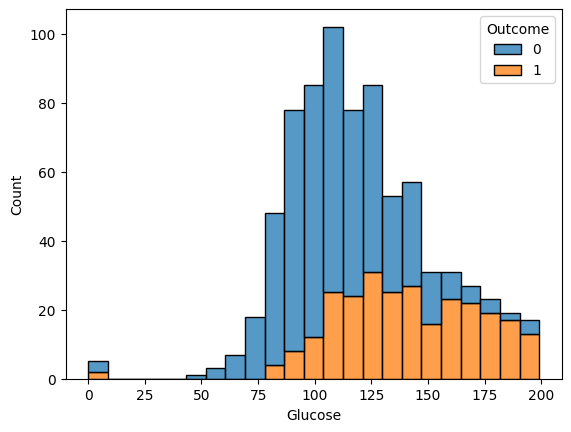

In [ ]:
sns.histplot(data=diabetes_df, x='Glucose', hue='Outcome', multiple='stack')

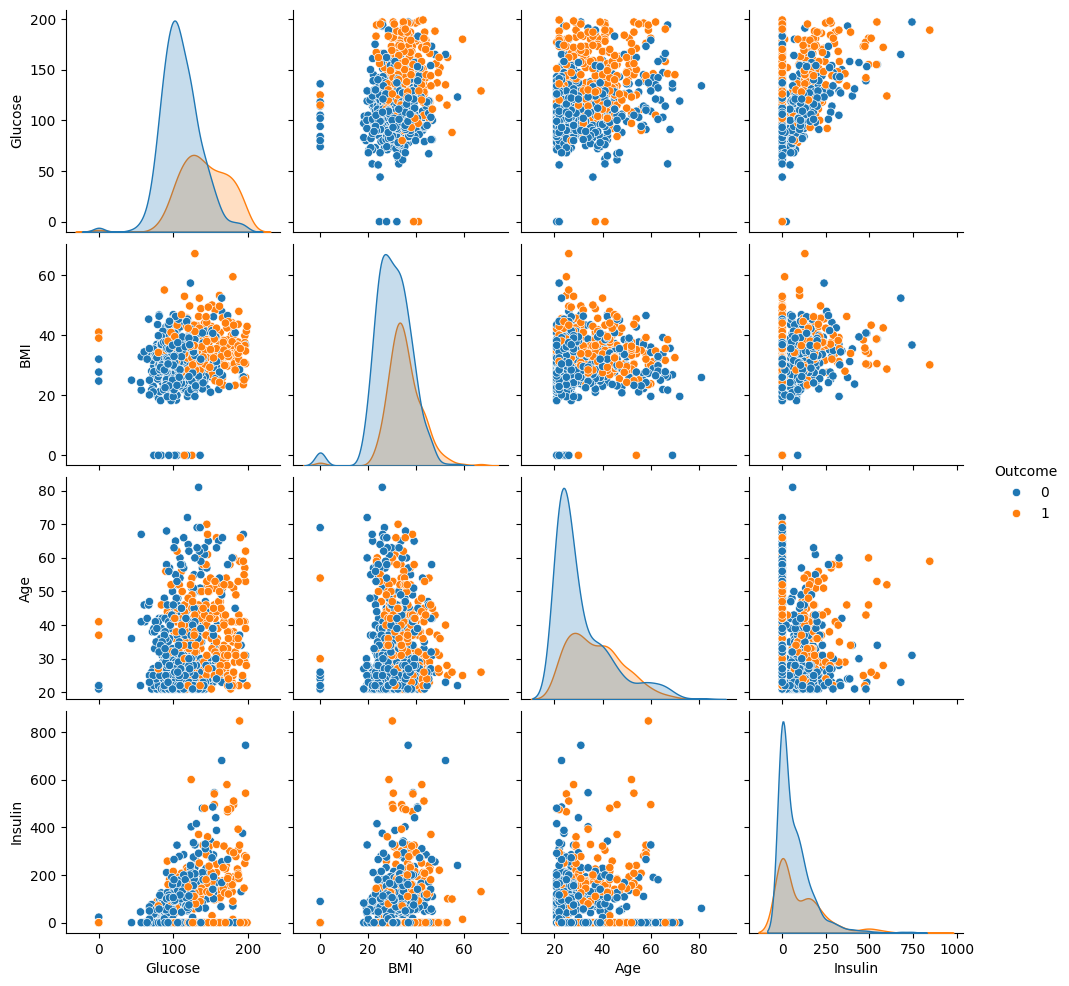

In [ ]:
# Making a pairplot based on the variables of glucose, BMI, age, and insulin level
sns.pairplot(diabetes_df, hue='Outcome', vars=['Glucose', 'BMI', 'Age', 'Insulin'])

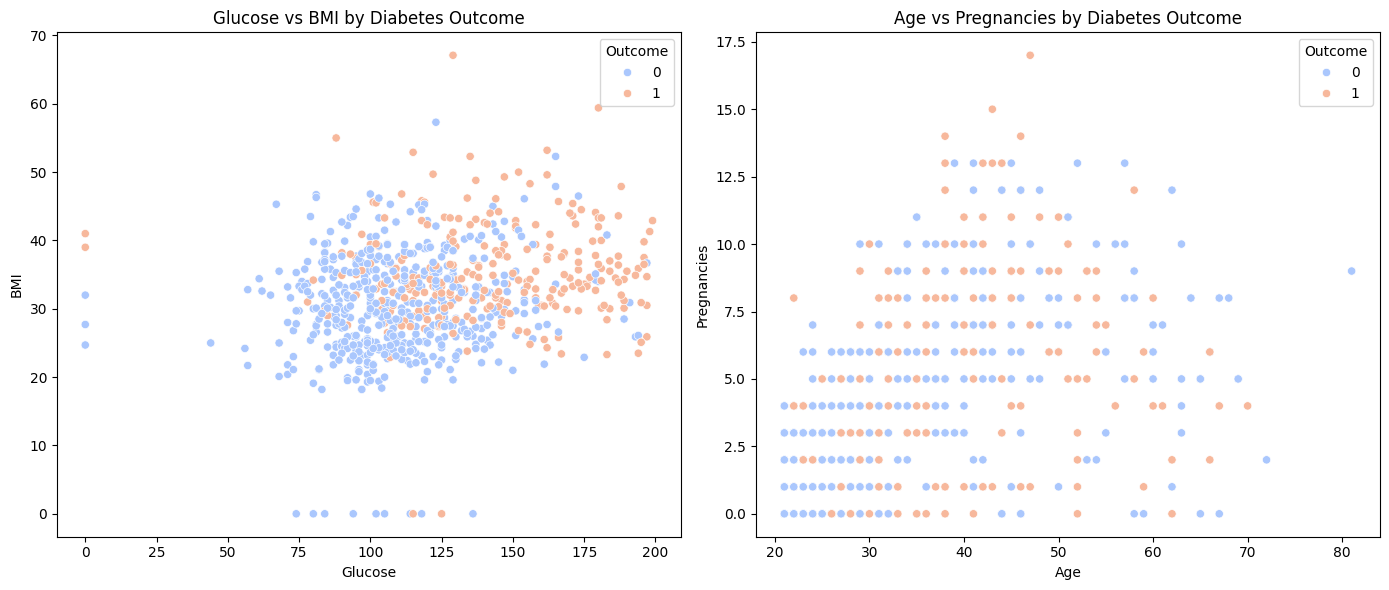

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# First scatter plot: Glucose vs BMI
sns.scatterplot(ax=axes[0], x='Glucose', y='BMI', hue='Outcome', data=diabetes_df, palette='coolwarm')
axes[0].set_title("Glucose vs BMI by Diabetes Outcome")
axes[0].set_xlabel("Glucose")
axes[0].set_ylabel("BMI")

# Second scatter plot: Age vs Pregnancies
sns.scatterplot(ax=axes[1], x='Age', y='Pregnancies', hue='Outcome', data=diabetes_df, palette='coolwarm')
axes[1].set_title("Age vs Pregnancies by Diabetes Outcome")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Pregnancies")

# Layout adjustment
plt.tight_layout()
plt.show()

Outcome
0    500
1    268
Name: count, dtype: int64


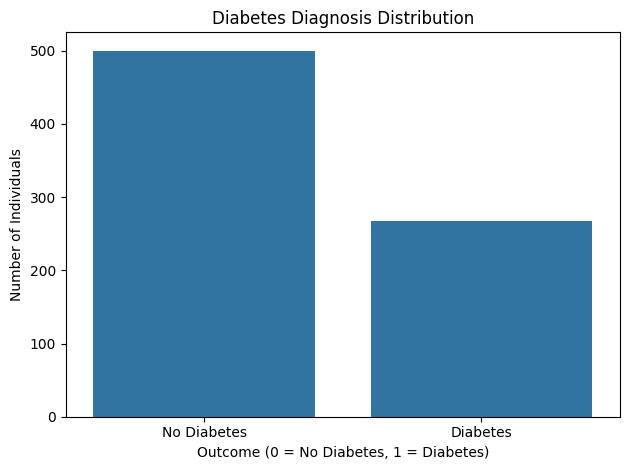

In [ ]:
# Plot and show who is diabetic and who is not
# 0 = Non-Diabetic
# 1 = Diabetic
print(diabetes_df.Outcome.value_counts())

sns.countplot(x='Outcome', data=diabetes_df)
plt.title('Diabetes Diagnosis Distribution')
plt.xlabel('Outcome (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Number of Individuals')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.tight_layout()
plt.show()

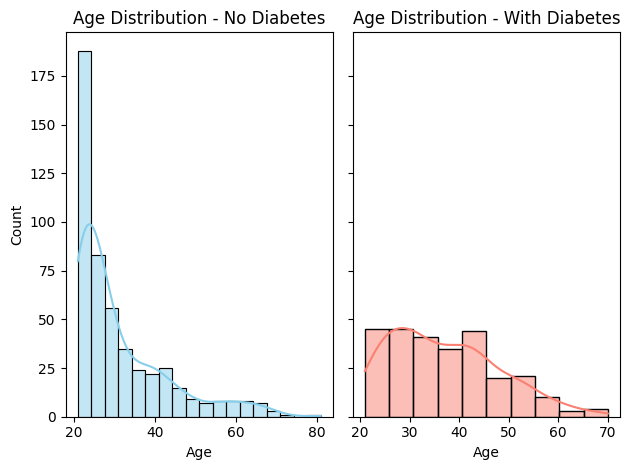

In [ ]:
fig, axes = plt.subplots(1, 2, sharey=True)

# Plot for Outcome = 0
sns.histplot(data=diabetes_df[diabetes_df["Outcome"] == 0], x="Age", ax=axes[0], kde=True, color="skyblue")
axes[0].set_title("Age Distribution - No Diabetes")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Plot for Outcome = 1
sns.histplot(data=diabetes_df[diabetes_df["Outcome"] == 1], x="Age", ax=axes[1], kde=True, color="salmon")
axes[1].set_title("Age Distribution - With Diabetes")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

<ipython-input-10-d7e095cfb4e3>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y="Glucose", data=diabetes_df, palette="pastel")


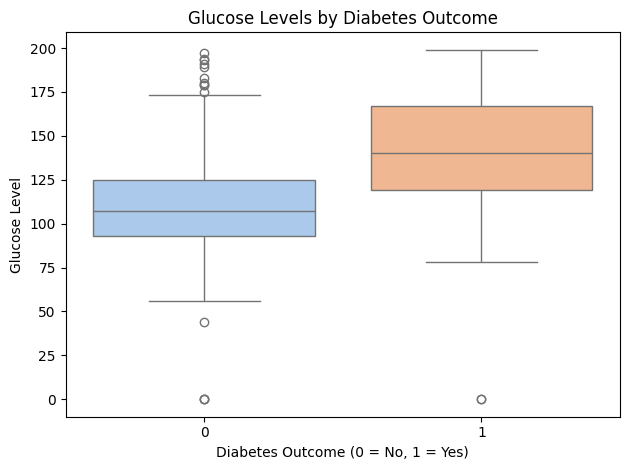

In [ ]:
# Determineing the glucose levels and diabtees

sns.boxplot(x="Outcome", y="Glucose", data=diabetes_df, palette="pastel")
plt.title("Glucose Levels by Diabetes Outcome")
plt.xlabel("Diabetes Outcome (0 = No, 1 = Yes)")
plt.ylabel("Glucose Level")
plt.tight_layout()
plt.show()

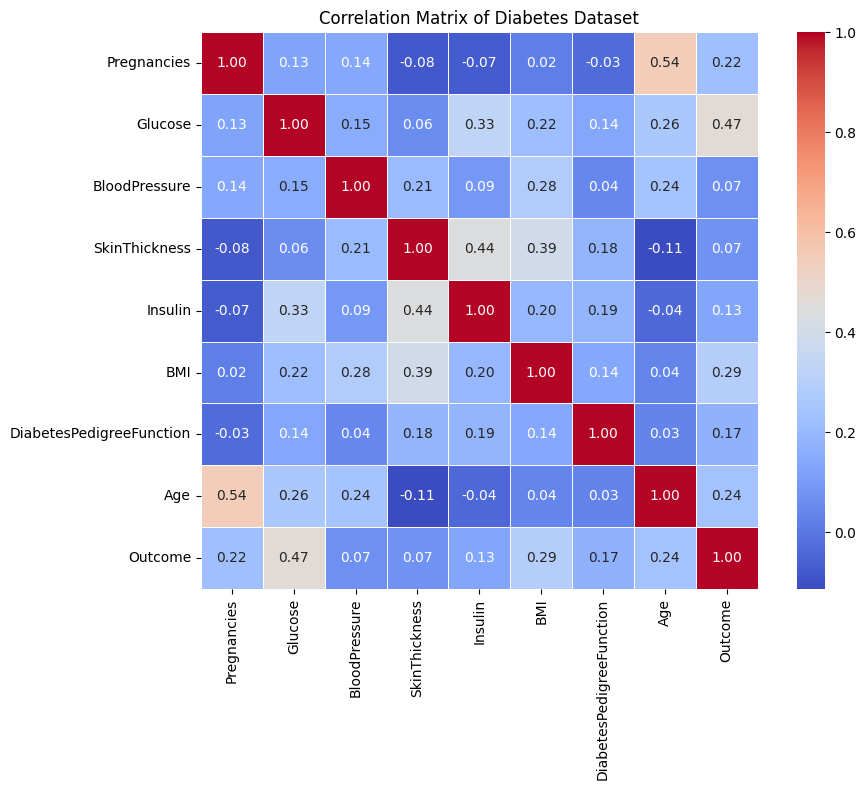

In [ ]:
# Creating a corrolation matrix
plt.figure(figsize=(10, 8))
corr = diabetes_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, linewidths=0.5)
plt.title("Correlation Matrix of Diabetes Dataset")
plt.tight_layout()
plt.show()

In [ ]:
# A look at diabetics Glucose, BMI, and Age compared to non-diabetics
print(diabetes_df[diabetes_df['Outcome'] == 1][['Glucose','BMI','Age']].describe())

print()

print(diabetes_df[diabetes_df['Outcome'] == 0][['Glucose','BMI','Age']].describe())

          Glucose         BMI         Age
count  268.000000  268.000000  268.000000
mean   141.257463   35.142537   37.067164
std     31.939622    7.262967   10.968254
min      0.000000    0.000000   21.000000
25%    119.000000   30.800000   28.000000
50%    140.000000   34.250000   36.000000
75%    167.000000   38.775000   44.000000
max    199.000000   67.100000   70.000000

        Glucose         BMI         Age
count  500.0000  500.000000  500.000000
mean   109.9800   30.304200   31.190000
std     26.1412    7.689855   11.667655
min      0.0000    0.000000   21.000000
25%     93.0000   25.400000   23.000000
50%    107.0000   30.050000   27.000000
75%    125.0000   35.300000   37.000000
max    197.0000   57.300000   81.000000
